In [2]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import sys
import os 
import calendar
from scipy.interpolate import interp1d
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import ds_grid, alps_ice, lon, lat, H, alps, get_season 

In [3]:
import rioxarray
import xarray as xr

da = rioxarray.open_rasterio("/bettik/PROJECTS/pr-regional-climate/mougina/sd75_grd", masked=True)
da = da.squeeze("band", drop=True)
da = da.rename({"x": "lon", "y": "lat"})

# Découper sur les Alpes
da_alpes = da.sel(lon=slice(4, 17), lat=slice(49, 43))

# Sauvegarder
ds = da_alpes.to_dataset(name="elevation_std")
ds.to_netcdf("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_std_alpes_250m.nc")
print("Done !", ds)

PermissionError: [Errno 13] Permission denied: '/bettik/PROJECTS/pr-regional-climate/mougina/gmted_std_alpes_250m.nc'

In [ ]:
data = ds["elevation_std"].values.astype(float)
print("min:", np.nanmin(data), "max:", np.nanmax(data))

In [ ]:
print("Valeurs valides:", np.sum(~np.isnan(data)))

In [ ]:
import rioxarray
import xarray as xr

da = rioxarray.open_rasterio("/bettik/PROJECTS/pr-regional-climate/mougina/topo_alpes/", masked=True)
da = da.squeeze("band", drop=True)
da = da.rename({"x": "lon", "y": "lat"})

# Découper sur les Alpes
da_alpes = da.sel(lon=slice(4, 17), lat=slice(49, 43))

# Sauvegarder
ds = da_alpes.to_dataset(name="elevation")
ds.to_netcdf("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_alpes_250m.nc")
print("Done !", ds)

Dimensions de la topo Alpes : (2400, 5760)
Rugosité Min : 0.0
Rugosité Max : 311.0


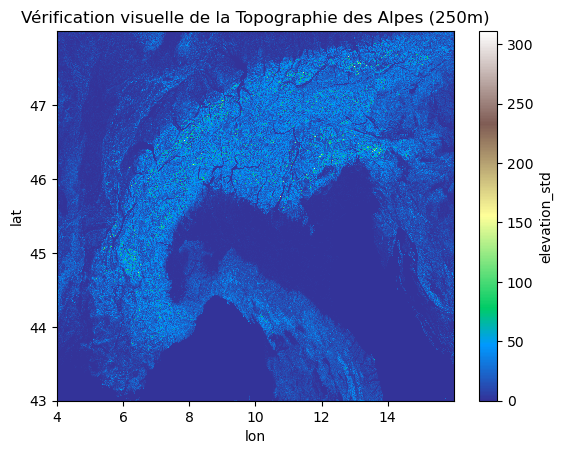

In [7]:

import xarray as xr
import matplotlib.pyplot as plt

# 1. On ouvre le fichier mondial en ignorant la variable de projection qui fait paniquer CDO
ds_topo = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_std_alpes_250m.nc")
topo_mondiale = ds_topo['elevation_std']

# 2. On découpe STRICTEMENT sur les Alpes (lon: 4 à 16, lat: 43 à 48)
# Attention : GMTED a souvent les latitudes inversées (du Nord au Sud), on utilise donc une méthode robuste :
lon1, lon2, lat1, lat2 = 4, 16, 43, 48
vrai_topo_alpes = topo_mondiale.sel(
    lon=slice(min(lon1, lon2), max(lon1, lon2)), 
    lat=slice(max(lat1, lat2), min(lat1, lat2))
)

# Si la sélection est vide, on tente dans l'autre sens pour les latitudes :
if vrai_topo_alpes.sizes['lat'] == 0:
    vrai_topo_alpes = topo_mondiale.sel(
        lon=slice(min(lon1, lon2), max(lon1, lon2)), 
        lat=slice(min(lat1, lat2), max(lat1, lat2))
    )

# 3. ON VÉRIFIE CE QU'IL Y A DEDANS (Crucial)
print("Dimensions de la topo Alpes :", vrai_topo_alpes.shape)
print("Rugosité Min :", float(vrai_topo_alpes.min()))
print("Rugosité Max :", float(vrai_topo_alpes.max()))

# On fait un plot rapide pour valider visuellement
vrai_topo_alpes.plot(cmap='terrain')
plt.title("Vérification visuelle de la Topographie des Alpes (250m)")
plt.show()

TypeError: Dimensions of C (1826, 500, 900) should be one smaller than X(900) and Y(500) while using shading='flat' see help(pcolormesh)

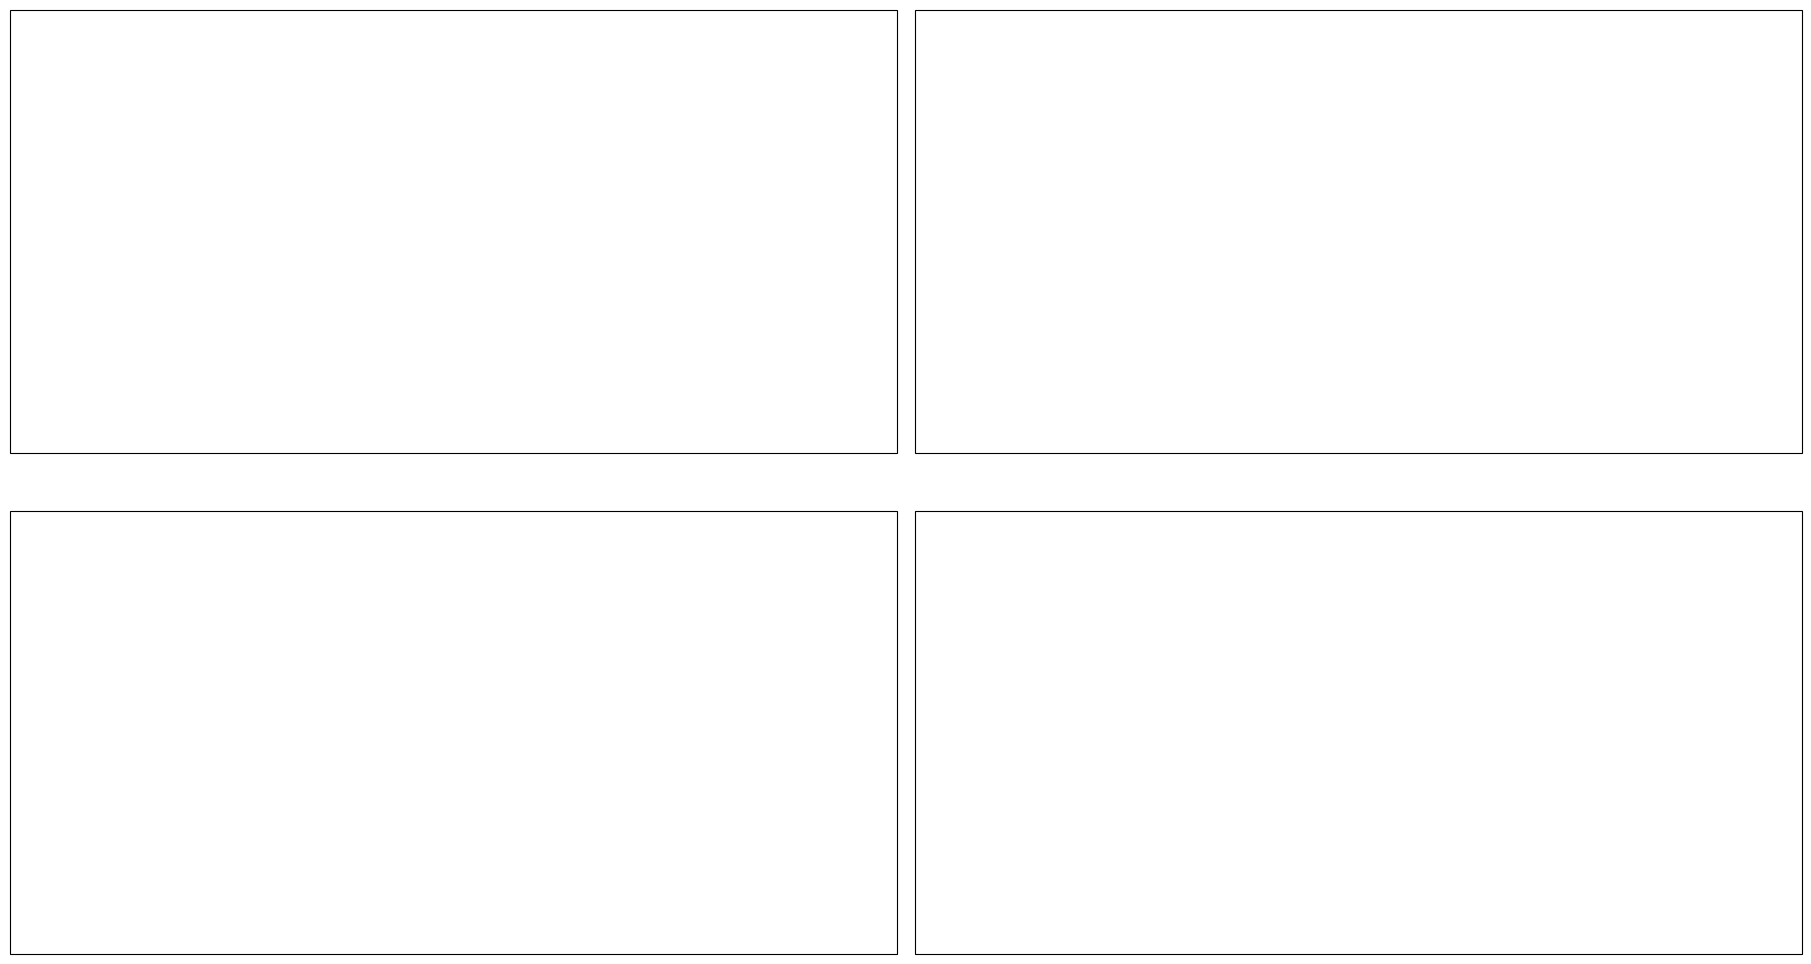

In [4]:

lon1, lon2 = 67.0, 76.0
lat1, lat2 = 36.0, 41.0

years_to_plot = [2017, 2018]

base_path = "/bettik/peyaudv/SNOW/Option13/scfg/SNOCAM_MODIS/v2.0"
file_pattern = os.path.join(base_path, "20[12][016789]", "*.nc")
all_files = sorted(glob.glob(file_pattern))
valid_files = []
for f in all_files:
    basename = os.path.basename(f)
    date_str = basename.split("-")[0]
    if "20160901" <= date_str <= "20210831":
        valid_files.append(f)
def preprocess(ds):
    for v in ds.variables:
        if "dtype" in ds[v].attrs:
            del ds[v].attrs["dtype"]

    ds = xr.decode_cf(ds)
    ds_cropped = ds.sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2))
    return ds_cropped
ds_all = xr.open_mfdataset(
    valid_files, preprocess=preprocess, combine="by_coords", parallel=True
)

scfg_all = ds_all["scfg"]
scfg_all = scfg_all.where((scfg_all >= 0) & (scfg_all <= 100), np.nan)

months = scfg_all.time.dt.month
years_attr = scfg_all.time.dt.year
season_year = xr.where(months == 12, years_attr + 1, years_attr)

# Définition des masques saisonniers
is_djf = (months == 12) | (months == 1) | (months == 2)
is_mam = (months == 3) | (months == 4) | (months == 5)
season_labels = np.array(["None"] * len(scfg_all.time), dtype=object)
season_labels[is_djf] = [f"{y}_DJF" for y in season_year[is_djf].values]
season_labels[is_mam] = [f"{y}_MAM" for y in season_year[is_mam].values]

scfg_all = scfg_all.assign_coords(season=("time", season_labels))
n_rows = len(years_to_plot)
fig, axs = plt.subplots(
    n_rows,
    2,
    figsize=(18, 5 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for i, yr in enumerate(years_to_plot):
    ax = axs[i] if n_rows > 1 else axs

    target_spring = f"{yr}_MAM"
    target_winter = f"{yr}_DJF"

    spring_pamir = scfg_all.where(
        scfg_all.season == target_spring, drop=True
    ).mean(dim="time")
    winter_pamir = scfg_all.where(
        scfg_all.where(scfg_all.season == target_winter, drop=True).mean(
            dim="time"
        )
    )
    im2 = ax[0].pcolormesh(
        winter_pamir.lon,
        winter_pamir.lat,
        winter_pamir,
        cmap="Blues",
        vmin=0,
        vmax=100,
        transform=ccrs.PlateCarree(),
    )
    ax[0].set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax[0].add_feature(cfeature.BORDERS, linestyle="-", alpha=0.5)
    ax[0].coastlines()
    ax[0].set_title(f"Mean Winter {yr} (DJF)")
    gl0 = ax[0].gridlines(draw_labels=True, color="gray", alpha=0.5, linewidth=0)
    gl0.top_labels = gl0.right_labels = False
    im1 = ax[1].pcolormesh(
        spring_pamir.lon,
        spring_pamir.lat,
        spring_pamir,
        cmap="Blues",
        vmin=0,
        vmax=100,
        transform=ccrs.PlateCarree(),
    )
    ax[1].set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax[1].add_feature(cfeature.BORDERS, linestyle="-", alpha=0.5)
    ax[1].coastlines()
    ax[1].set_title(f"Mean Spring {yr} (MAM)")
    gl1 = ax[1].gridlines(draw_labels=True, color="gray", alpha=0.5, linewidth=0)
    gl1.top_labels = gl1.right_labels = False

cbar = fig.colorbar(
    im2, ax=axs, label="SCF MODIS GF (%)", fraction=0.02, aspect=50, pad=0.02
)
plt.suptitle(
    "Gap-Filled SCF in Pamir during Winter and Spring seasons", size=16
)

# Sauvegarde et affichage
output_dir = "/home/mougina/mes_analyses/carte_SCF_SCD/"
os.makedirs(output_dir, exist_ok=True)
#plt.savefig(os.path.join(output_dir, "carte_pamir_SCF.png"), dpi=150)
plt.show()